In [1]:
import numpy as np
import pandas as pd
import linearsolve as ls
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

# Class 14: Prescott's RBC Model

## Import Data

In [2]:
# Read rbc_data.csv into a Pandas DataFrame with the first column set as the index and parse_dates=True
df = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/computational-macroeconomics/master/Data/Csv/rbc_data_actual_trend_cycle.csv',index_col=0,parse_dates=True)

# Set base year
base_year = '2012'

## Estimate TFP Process

In [3]:
# Create a new column to df called tfp_cycle equal to the log difference between actual TFP and it's trend:
df['tfp_cycle'] = np.log(df['tfp']/df['tfp_trend'])

# Create a new column to df called tfp_cycle_lag that, for each date, contains values 
# in 'tfp_cycle' at the previous date
df['tfp_cycle_lag'] = df['tfp_cycle'].shift()

# Use dropna() method on df to remove the row iwth the missing value
df= df.dropna()

# Create variable 'X' to be the independent variable of the OLS model. Do not add a constant to X
X = df['tfp_cycle_lag']

# Create variable 'Y' to be the dependent variable of the OLS model.
Y = df['tfp_cycle']

# Create a variable called 'model' that initializes the OLS model
model = sm.OLS(Y,X)

# Create a variable called 'results' that stores the results of the estimated OLS model
results = model.fit()

# Print output of summary2() mdethod of results
print(results.summary2())

                        Results: Ordinary least squares
Model:                  OLS              Adj. R-squared (uncentered): 0.549     
Dependent Variable:     tfp_cycle        AIC:                         -2171.1302
Date:                   2022-10-25 14:44 BIC:                         -2167.4365
No. Observations:       297              Log-Likelihood:              1086.6    
Df Model:               1                F-statistic:                 362.8     
Df Residuals:           296              Prob (F-statistic):          2.35e-53  
R-squared (uncentered): 0.551            Scale:                       3.9020e-05
------------------------------------------------------------------------------------
                    Coef.      Std.Err.        t        P>|t|      [0.025     0.975]
------------------------------------------------------------------------------------
tfp_cycle_lag       0.7454       0.0391     19.0472     0.0000     0.6684     0.8225
-------------------------------------

## Solve the Three Business Cycle Models

### Stochastic Solow Model

In [4]:
# Input model parameters
parameters = pd.Series(dtype=float)
parameters['rho'] = rho = results.params['tfp_cycle_lag']
parameters['sigma_squared'] = results.resid.std()**2
parameters['alpha'] = 0.35
parameters['delta'] = 0.025
parameters['s'] = np.mean(df['investment']/df['gdp'])

# Create variable called 'var_names' that stores the variable names in a list with state variables ordered first
var_names = ['a','k','y','c','i']

# Create variable called 'shock_names' that stores an exogenous shock name for each state variable.
shock_names = ['e_a']

# Define a function that evaluates the equilibrium conditions. PROVIDED
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters. PROVIDED
    p = parameters
    
    # Current variables. PROVIDED
    cur = variables_current
    
    # Forward variables. PROVIDED
    fwd = variables_forward
        
    # Production function
    production_function = cur.a*cur.k**p.alpha - cur.y
    
    # Capital evolution
    capital_evolution = p.s*cur.a*cur.k**p.alpha + (1 - p.delta)*cur.k - fwd.k
    
    # Consumption function
    consumption_function = (1-p.s)*cur.y  - cur.c
    
    # Goods market clearing
    market_clearing = cur.i + cur.c - cur.y
    
    # Exogenous tfp
    tfp_process = p.rho*np.log(cur.a) - np.log(fwd.a)
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
        production_function,
        capital_evolution,
        consumption_function,
        market_clearing,
        tfp_process
        ])

# Initialize the model into a variable named 'rbc_model'
stoch_solow_model = ls.model(equations = equilibrium_equations,
                 n_states=2,
                 n_exo_states=1,
                 var_names=var_names,
                 shock_names=shock_names,
                 parameters=parameters)


# Compute the steady state numerically using linearsolve
guess = [1,4,1,1,1]
stoch_solow_model.compute_ss(guess)

# Find the log-linear approximation around the non-stochastic steady state and solve
stoch_solow_model.approximate_and_solve()

### Baseline RBC Model without Labor

In [5]:
# Input model parameters
parameters = pd.Series(dtype=float)
parameters['rho'] = rho = results.params['tfp_cycle_lag']
parameters['sigma_squared'] = results.resid.std()**2
parameters['alpha'] = 0.35
parameters['delta'] = 0.025
parameters['beta'] = 0.99
parameters['s'] = np.mean(df['investment']/df['gdp'])

# Create variable called 'var_names' that stores the variable names in a list with state variables ordered first
var_names = ['a','k','y','c','i']

# Create variable called 'shock_names' that stores an exogenous shock name for each state variable.
shock_names = ['e_a']

# Define a function that evaluates the equilibrium conditions. PROVIDED
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters. PROVIDED
    p = parameters
    
    # Current variables. PROVIDED
    cur = variables_current
    
    # Forward variables. PROVIDED
    fwd = variables_forward
        
    # Production function
    production_function = cur.a*cur.k**p.alpha - cur.y
    
    # Capital evolution
    capital_evolution = cur.i + (1 - p.delta)*cur.k - fwd.k
    
    # Consumption function
    euler_equation = p.beta/fwd.c*(p.alpha*fwd.a*fwd.k**(p.alpha-1)+1-p.delta) - 1/cur.c
    
    # Goods market clearing
    market_clearing = cur.i + cur.c - cur.y
    
    # Exogenous tfp
    tfp_process = p.rho*np.log(cur.a) - np.log(fwd.a)
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
        production_function,
        capital_evolution,
        euler_equation,
        market_clearing,
        tfp_process
        ])

# Initialize the model into a variable named 'rbc_model'
rbc_model = ls.model(equations = equilibrium_equations,
                 n_states=2,
                 n_exo_states=1,
                 var_names=var_names,
                 shock_names=shock_names,
                 parameters=parameters)


# Compute the steady state numerically using linearsolve
guess = [1,10,1,1,1]
rbc_model.compute_ss(guess)

# Find the log-linear approximation around the non-stochastic steady state and solve
rbc_model.approximate_and_solve()

### Kydland and Prescott's RBC Model with Labor

In [6]:
# Create a variable called 'parameters' that stores the model parameter values in a Pandas Series
parameters = pd.Series(dtype=float)
parameters['rho'] = .75
parameters['sigma_squared'] = 0.006**2
parameters['beta'] = 0.99
parameters['phi'] = 1.7317
parameters['alpha'] = 0.35
parameters['delta'] = 0.025

# Create variable called 'var_names' that stores the variable names in a list with state variables ordered first
var_names = ['a','k','y','c','i','l']

# Create variable called 'shock_names' that stores an exogenous shock name for each state variable.
shock_names = ['e_a']

# Define a function that evaluates the equilibrium conditions of the model solved for zero. PROVIDED
def equilibrium_equations(variables_forward,variables_current,parameters):
    
    # Parameters. PROVIDED
    p = parameters
    
    # Current variables. PROVIDED
    cur = variables_current
    
    # Forward variables. PROVIDED
    fwd = variables_forward

    # Euler equation
    euler_equation = p.beta*(p.alpha*fwd.a*fwd.k**(p.alpha-1)*fwd.l**(1-p.alpha)+1-p.delta)/fwd.c - 1/cur.c
    
    # Labor-labor choise
    labor_leisure = (1-p.alpha)*cur.a*cur.k**p.alpha*cur.l**(-p.alpha)/cur.c - p.phi/(1-cur.l)
    
    # Production function
    production_function = cur.a*cur.k**p.alpha*cur.l**(1-p.alpha) - cur.y
    
    # Capital evolution
    capital_evolution = cur.i + (1 - p.delta)*cur.k - fwd.k
    
    # Market clearing
    market_clearing = cur.c+cur.i - cur.y
    
    # Exogenous tfp
    tfp_process = p.rho*np.log(cur.a) - np.log(fwd.a)
    
    
    # Stack equilibrium conditions into a numpy array
    return np.array([
        euler_equation,
        labor_leisure,
        production_function,
        capital_evolution,
        market_clearing,
        tfp_process
        ])

# Initialize the model into a variable named 'rbc_model'
full_rbc_model = ls.model(equations = equilibrium_equations,
                 n_states=2,
                 n_exo_states=1,
                 var_names=var_names,
                 shock_names=shock_names,
                 parameters=parameters)

# Compute the steady state numerically using .compute_ss() method of rbc_model
guess = [1,4,1,1,1,0.5]
full_rbc_model.compute_ss(guess)

# Find the log-linear approximation around the non-stochastic steady state and solve using .approximate_and_solve() method of rbc_model
full_rbc_model.approximate_and_solve()

## Simulate Data Using Estimated TFP Residuals

In [7]:
# Store estimated TFP shocks along with array of zeros to represent capital shocks.
epsilon = np.array([results.resid,np.zeros(len(results.resid))]).T

# Simulate Stochastic Solow growth model
simulated_data_solow = pd.DataFrame(ls.ir(stoch_solow_model.f,stoch_solow_model.p,epsilon).T,columns = ['tfp_cycle','capital_cycle','gdp_cycle','consumption_cycle','investment_cycle'],index=results.resid.index)

# Simulate Baseline RBC model (without labor)
simulated_baseline_rbc = pd.DataFrame(ls.ir(rbc_model.f,rbc_model.p,epsilon).T,columns = ['tfp_cycle','capital_cycle','gdp_cycle','consumption_cycle','investment_cycle'],index=results.resid.index)

# Simulate Kydland Prescott model (with labor)
simulated_full_rbc = pd.DataFrame(ls.ir(full_rbc_model.f,full_rbc_model.p,epsilon).T,columns = ['tfp_cycle','capital_cycle','gdp_cycle','consumption_cycle','investment_cycle','labor_cycle'],index=results.resid.index)

# Compute impulse responses for Kydland Prescott model (with labor)
full_rbc_model.impulse(T=26,t0=5)

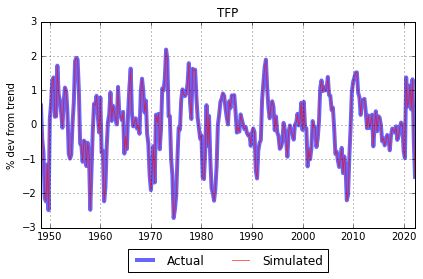

In [8]:
# Plot actual TFP and TFP simulated using estimated residuals.
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['tfp_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_data_solow['tfp_cycle']*100,'r-',lw=1,alpha=0.6,label='Simulated')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('TFP')

fig.tight_layout()

### Plots and Statistics

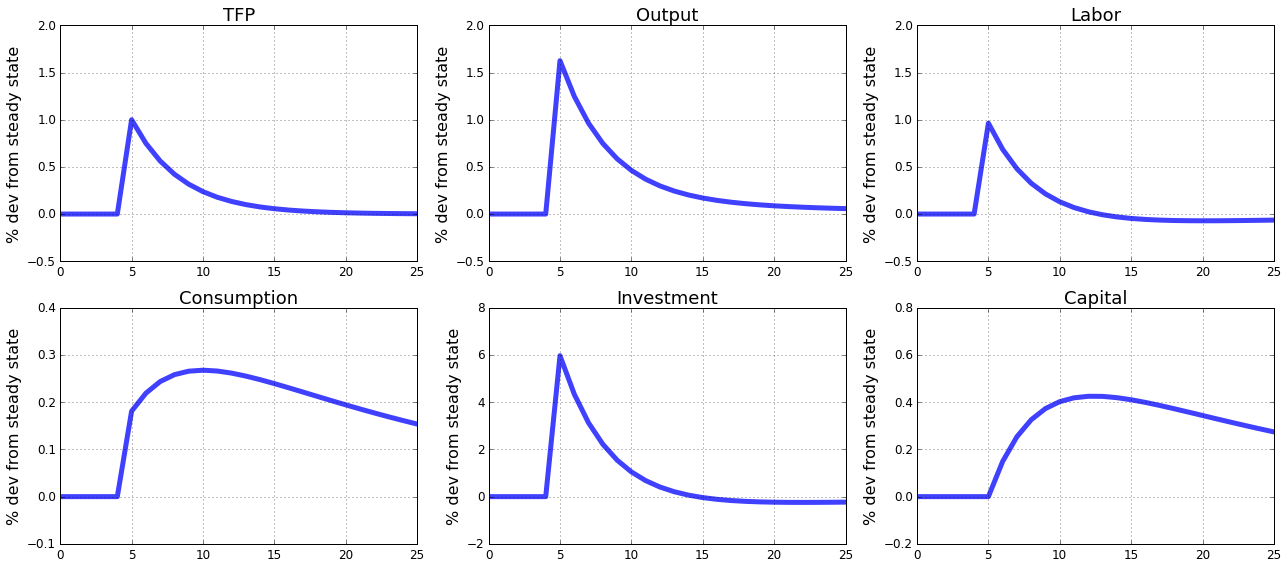

In [9]:
# Create figure.
fig = plt.figure(figsize=(18,8))

# Create upper-left axis.
ax = fig.add_subplot(2,3,1)
ax.plot(full_rbc_model.irs['e_a']['a']*100,'b',lw=5,alpha=0.75)
ax.set_title('TFP',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.5,2])
ax.grid()

# Create upper-center axis.
ax = fig.add_subplot(2,3,2)
ax.plot(full_rbc_model.irs['e_a']['y']*100,'b',lw=5,alpha=0.75)
ax.set_title('Output',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.5,2])
ax.grid()

# Create upper-right axis.
ax = fig.add_subplot(2,3,3)
ax.plot(full_rbc_model.irs['e_a']['l']*100,'b',lw=5,alpha=0.75)
ax.set_title('Labor',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.5,2])
ax.grid()

# Create lower-left axis.
ax = fig.add_subplot(2,3,4)
ax.plot(full_rbc_model.irs['e_a']['c']*100,'b',lw=5,alpha=0.75)
ax.set_title('Consumption',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.1,0.4])
ax.grid()

# Create lower-center axis.
ax = fig.add_subplot(2,3,5)
ax.plot(full_rbc_model.irs['e_a']['i']*100,'b',lw=5,alpha=0.75)
ax.set_title('Investment',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-2,8])
ax.grid()

# Create lower-right axis.
ax = fig.add_subplot(2,3,6)
ax.plot(full_rbc_model.irs['e_a']['k']*100,'b',lw=5,alpha=0.75)
ax.set_title('Capital',fontsize=18)
ax.set_ylabel('% dev from steady state',fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylim([-0.2,0.8])
ax.grid()

fig.tight_layout()


# Save image and make LaTex figure
figName = '014_intro_prescott_rbc_gdp_irs'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Kydland and Prescott RBC model with labor.} Impulse responses to a one percent shock to TFP in period 5.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

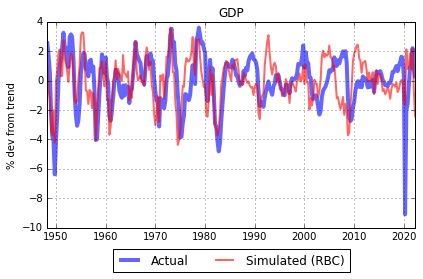

In [10]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['gdp_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_full_rbc['gdp_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('GDP')

fig.tight_layout()

# Save image and make LaTex figure
figName = '014_intro_prescott_rbc_gdp'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{GDP.} Actual and simulated data from Prescott\'s RBC model for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

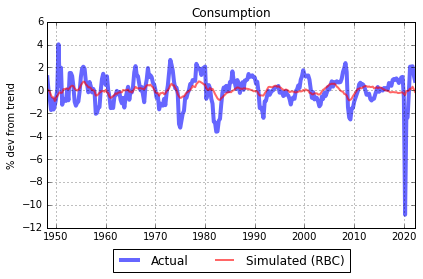

In [11]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['consumption_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_full_rbc['consumption_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Consumption')

fig.tight_layout()

# Save image and make LaTex figure
figName = '014_intro_prescott_rbc_consumption'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Consumption.} Actual and simulated data from Prescott\'s RBC model for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

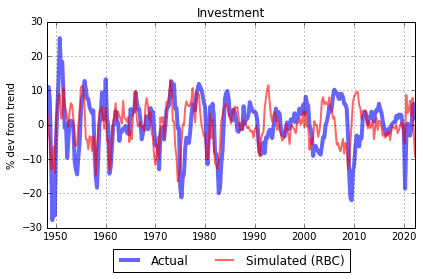

In [12]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['investment_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_full_rbc['investment_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Investment')

fig.tight_layout()

# Save image and make LaTex figure
figName = '014_intro_prescott_rbc_investment'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Investment.} Actual and simulated data from Prescott\'s RBC model for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

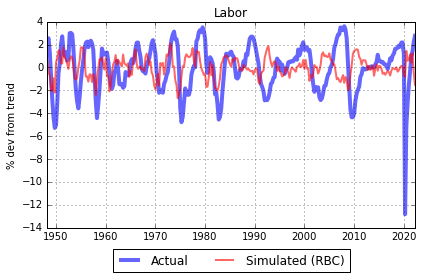

In [13]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(1,1,1)
ax1.plot(df['hours_cycle']*100,'-',lw=4,alpha=0.6,label='Actual')
ax1.plot(simulated_full_rbc['labor_cycle']*100,'r-',lw=2,alpha=0.6,label='Simulated (RBC)')
ax1.set_ylabel('% dev from trend')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.075),ncol=2)
ax1.grid()
ax1.set_title('Labor')

fig.tight_layout()

# Save image and make LaTex figure
figName = '014_intro_prescott_rbc_labor'
plt.savefig('fig_'+figName+'.png',bbox_inches='tight',dpi=120)

nf = open('figure_'+figName+'.tex', 'w')
nf.write('\\begin{figure}[h] \\caption{\\label{fig_'+figName+'} \\textbf{Labor.} Actual and simulated data from Prescott\'s RBC model for the US from '+df.index[0].strftime('%B %Y')+' to '+df.index[-1].strftime('%B %Y')+'. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\\includegraphics[height = 4.5cm]{fig_'+figName+'.png}\\end{center}\n')
nf.write('\\end{figure}')
nf.close()

In [14]:
# Construct DataFrame of standard deviations
stds_df = pd.DataFrame({
    'Actual':df[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values*100,
    'RBC (w/o labor)':simulated_baseline_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values*100,
    'RBC (w/ labor)':simulated_full_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].std().round(4).values*100
},index=['Output','Consumption','Investment'])

stds_df.loc['Labor'] = [df.std().round(4)['hours_cycle']*100,'$-$',simulated_full_rbc.std().round(4)['labor_cycle']*100]

# Construct LaTeX table
tabName = '014_intro_prescott_rbc_stds'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Standard deviations.} Actual data and data simulated from RBC models with and without labor. Units are percent deviations from trend. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lccc',escape=False)+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show standard deviations
stds_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6689/3110887466.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+stds_df.to_latex(column_format='lccc',escape=False)+'\\end{center}\n')


,Actual,RBC (w/o labor),RBC (w/ labor)
Output,1.69,0.94,1.53
Consumption,1.34,0.22,0.33
Investment,7.41,3.39,5.60
Labor,2.06,$-$,0.91


In [15]:
# Construct DataFrame of correlations
corrs_df = pd.DataFrame({
    'Actual':df[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values,
    'RBC (w/o labor)':simulated_baseline_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values,
    'RBC (w/ labor)':simulated_full_rbc[['gdp_cycle','consumption_cycle','investment_cycle']].corr()['gdp_cycle'].round(2).values

},index=['Output','Consumption','Investment',])

corrs_df.loc['Labor'] = [df.corr()['gdp_cycle'].round(2)['hours_cycle'],'$-$',simulated_full_rbc.corr()['gdp_cycle'].round(2)['labor_cycle']]

corrs_df = corrs_df.loc[['Consumption','Investment','Labor']]

# Construct LaTeX table
tabName = '014_intro_prescott_rbc_corrs'

nf = open('table_'+tabName+'.tex', 'w')
nf.write('\\begin{table}[h] \\caption{\\label{tab'+tabName+'} \\textbf{Correlations with GDP.} Actual data and simulated data. {\\tiny Source: FRED}.}\n')
nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lccc',escape=False)+'\\end{center}\n')
nf.write('\\end{table}')
nf.close()

# Show correlations
corrs_df

/var/folders/36/tyk09l294j7b2stxnfxym2200000gp/T/ipykernel_6689/1103669742.py:18: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  nf.write('\\begin{center}\\hspace*{-.5cm}\n\n'+corrs_df.to_latex(column_format='lccc',escape=False)+'\\end{center}\n')


,Actual,RBC (w/o labor),RBC (w/ labor)
Consumption,0.81,0.61,0.59
Investment,0.84,0.99,0.99
Labor,0.88,$-$,0.98
